In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR
from sklearn.datasets import make_blobs, make_moons, make_circles, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
X, y = make_blobs(centers=2, random_state=55)
# print(data[0])
model = SVC(kernel = 'linear')
model.fit(X, y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [38]:
# print(X)
print(model.predict([[1.003234, 5.234823848632]]))

[0]


In [39]:
print(np.unique(y))

[0 1]


[[ 1.09583081  0.97726185  0.85869289  0.74012393  0.62155497  0.50298601
   0.38441705  0.26584809  0.14727913  0.02871017 -0.08985879 -0.20842775
  -0.32699671 -0.44556567 -0.56413463 -0.68270359 -0.80127255 -0.9198415
  -1.03841046 -1.15697942 -1.27554838 -1.39411734 -1.5126863  -1.63125526
  -1.74982422 -1.86839318 -1.98696214 -2.1055311  -2.22410006 -2.34266902]
 [ 1.14363277  1.02506381  0.90649485  0.78792589  0.66935693  0.55078798
   0.43221902  0.31365006  0.1950811   0.07651214 -0.04205682 -0.16062578
  -0.27919474 -0.3977637  -0.51633266 -0.63490162 -0.75347058 -0.87203954
  -0.9906085  -1.10917746 -1.22774642 -1.34631538 -1.46488434 -1.58345329
  -1.70202225 -1.82059121 -1.93916017 -2.05772913 -2.17629809 -2.29486705]
 [ 1.19143474  1.07286578  0.95429682  0.83572786  0.7171589   0.59858994
   0.48002098  0.36145202  0.24288306  0.1243141   0.00574514 -0.11282381
  -0.23139277 -0.34996173 -0.46853069 -0.58709965 -0.70566861 -0.82423757
  -0.94280653 -1.06137549 -1.17994445

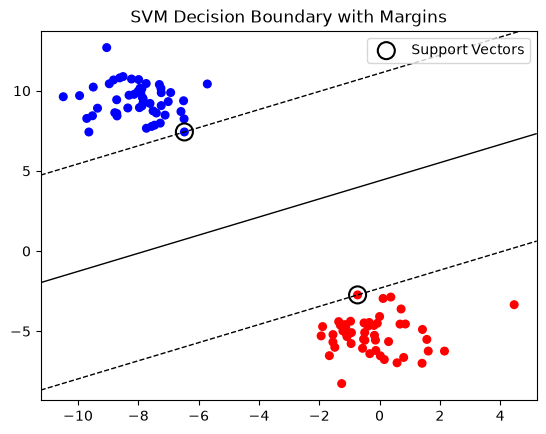

In [30]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30)
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')

#get current axis
ax = plt.gca()

#return current visible range of plot as tuple
xlim = ax.get_xlim()
ylim = ax.get_ylim()

#create 30 evenly space, linespace(start, stop, increasing)
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

# given the values by (row, column) by the size len(xx), len(yy)
YY, XX = np.meshgrid(yy, xx)
# print(YY)
# print(XX)

#stack two array xx and yy and then transpose it
xy = np.vstack([XX.ravel(), YY.ravel()]).T
# print(xy)

Z = model.decision_function(xy).reshape(XX.shape)
print(Z)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
           linestyles=['--', '-', '--'], linewidths=1)

plt.legend()
plt.title("SVM Decision Boundary with Margins")
plt.show()

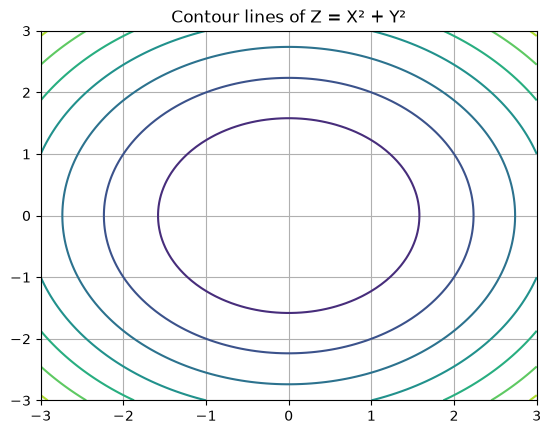

In [52]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2   # height = distance from origin, squared

# plt.contour(X, Y, Z, levels=[1, 4, 9], colors='k')
plt.contour(X, Y, Z)
plt.title("Contour lines of Z = X² + Y²")
plt.grid()
plt.show()

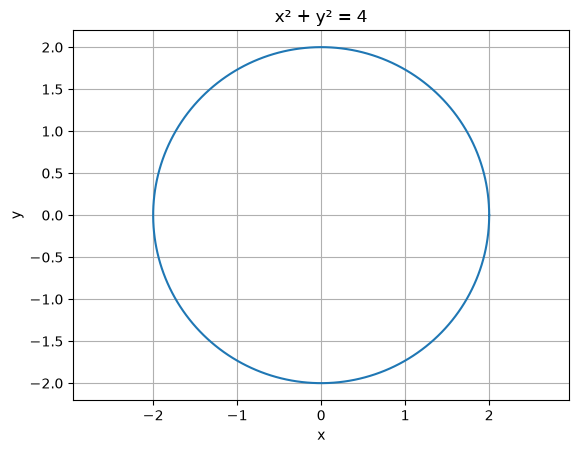

In [57]:
theta = np.linspace(0, 2*np.pi, 400)

x = 2 * np.cos(theta)
y = 2 * np.sin(theta)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("x² + y² = 4")
plt.axis("equal")      # Makes the circle look round
plt.grid(True)
plt.show()

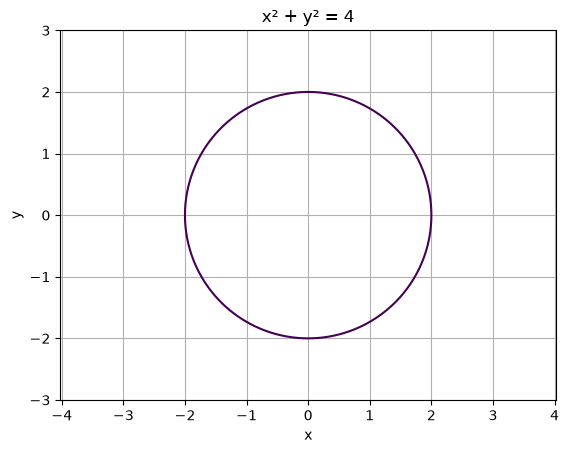

In [58]:
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)

X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2 - 4

plt.contour(X, Y, Z, levels=[0])

plt.xlabel("x")
plt.ylabel("y")
plt.title("x² + y² = 4")
plt.axis("equal")
plt.grid(True)
plt.show()